# Advanced learning laboratory: Bayesian network structure through order space

For a decomposable Bayesian-network score, summing over all DAGs consistent with a fixed variable order is much easier than summing over all DAGs directly. If $\mathrm{Pred}_i(\prec)$ denotes variables preceding $i$, then an order score factorizes as

$$
S(\prec)=\prod_i \sum_{\mathrm{Pa}_i\subseteq \mathrm{Pred}_i(\prec)} s_i(\mathrm{Pa}_i).
$$

This notebook uses a small Gaussian example in which every order can be enumerated exactly. We then run MCMC on permutations and compare the empirical order posterior with the exact one.

In [1]:
CHAPTER_DIR="ch14"

from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx

CWD = Path.cwd()
if CWD.name.startswith("ch"):
    NOTEBOOK_DIR = CWD
elif (CWD / "notebooks" / CHAPTER_DIR).exists():
    NOTEBOOK_DIR = CWD / "notebooks" / CHAPTER_DIR
else:
    NOTEBOOK_DIR = CWD
FIG_DIR = NOTEBOOK_DIR / "figs"
FIG_DIR.mkdir(parents=True, exist_ok=True)
RNG = np.random.default_rng(577)

plt.rcParams.update({
    "font.size": 15,
    "axes.titlesize": 17,
    "axes.labelsize": 15,
    "xtick.labelsize": 13,
    "ytick.labelsize": 13,
    "legend.fontsize": 12,
    "figure.titlesize": 18,
})

def save_figure(fig, stem):
    fig.savefig(FIG_DIR / f"{stem}.pdf", bbox_inches="tight")
    fig.savefig(FIG_DIR / f"{stem}.png", dpi=240, bbox_inches="tight")
    print("Saved", stem)

def draw_dark_nodes(G, pos, labels=None, ax=None, node_size=1200, arrows=False, **kwargs):
    if ax is None: ax=plt.gca()
    nx.draw_networkx_nodes(G, pos, node_size=node_size, node_color="#303030", edgecolors="black", ax=ax)
    nx.draw_networkx_labels(G, pos, labels=labels, font_color="white", font_size=13, ax=ax)
    nx.draw_networkx_edges(G, pos, arrows=arrows, arrowsize=20, width=1.8, ax=ax, **kwargs)
    return ax

def annotate_heatmap(ax, image, values, fmt=".2f"):
    arr=np.asarray(values)
    lo,hi=np.nanmin(arr),np.nanmax(arr)
    mid=(lo+hi)/2
    for i in range(arr.shape[0]):
        for j in range(arr.shape[1]):
            color="white" if arr[i,j] < mid else "black"
            ax.text(j,i,format(arr[i,j],fmt),ha="center",va="center",color=color,fontsize=11)

In [2]:
from itertools import permutations, combinations
from scipy.special import logsumexp
n=5; S=600
# linear Gaussian DAG 0->2, 1->2, 2->3, 1->4
Wtrue=np.zeros((n,n)); Wtrue[0,2]=.9; Wtrue[1,2]=-.8; Wtrue[2,3]=.75; Wtrue[1,4]=.65
X=np.zeros((S,n)); eps=RNG.normal(size=(S,n))
for j in range(n):
    X[:,j]=eps[:,j]+X@Wtrue[:,j]
# local BIC score for regressing node j on parents
cache={}
def local_score(j,pa):
    pa=tuple(sorted(pa)); key=(j,pa)
    if key in cache:return cache[key]
    y=X[:,j]
    if pa:
        Z=np.column_stack([np.ones(S),X[:,pa]]); coef=np.linalg.lstsq(Z,y,rcond=None)[0]; r=y-Z@coef; k=len(pa)+2
    else:
        r=y-y.mean(); k=2
    var=max(np.mean(r*r),1e-12)
    ll=-.5*S*(np.log(2*np.pi*var)+1)
    bic=ll-.5*k*np.log(S); cache[key]=bic; return bic

def order_score(order,max_pa=2):
    total=0.; pred=[]
    for j in order:
        vals=[]
        for r in range(min(max_pa,len(pred))+1):
            for pa in combinations(pred,r): vals.append(local_score(j,pa))
        total+=logsumexp(vals); pred.append(j)
    return total
orders=list(permutations(range(n))); ls=np.array([order_score(o) for o in orders]); post=np.exp(ls-logsumexp(ls))
print('top order:',orders[np.argmax(post)],'posterior',post.max())
# MCMC adjacent/random swap
cur=list(orders[0]); cur_s=order_score(cur); counts={o:0 for o in orders}; burn=5000; steps=60000
for it in range(steps):
    prop=cur.copy(); a,b=RNG.choice(n,2,replace=False); prop[a],prop[b]=prop[b],prop[a]; ps=order_score(prop)
    if np.log(RNG.random())<min(0,ps-cur_s): cur,cur_s=prop,ps
    if it>=burn: counts[tuple(cur)]+=1
emp=np.array([counts[o] for o in orders],float); emp/=emp.sum()
print('TV distance MCMC vs exact:',.5*np.abs(emp-post).sum())

top order: (0, 1, 2, 4, 3) posterior 0.08714833913197163


TV distance MCMC vs exact: 0.021110871247280966


Saved ch14_01_order_posterior_mcmc


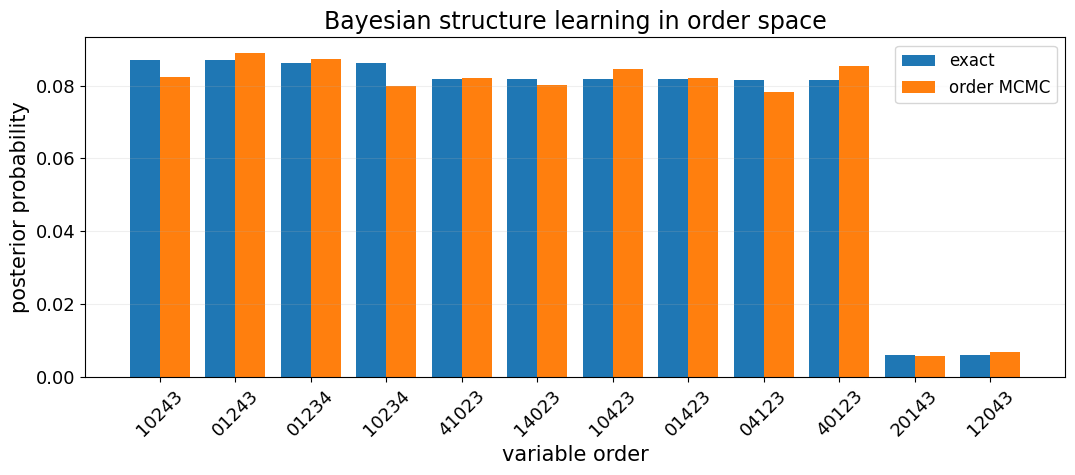

In [3]:
rank=np.argsort(post)[::-1][:12]
fig,ax=plt.subplots(figsize=(11,5)); x=np.arange(len(rank)); ax.bar(x-.2,post[rank],.4,label='exact'); ax.bar(x+.2,emp[rank],.4,label='order MCMC'); ax.set_xticks(x,[''.join(map(str,orders[i])) for i in rank],rotation=45); ax.set_ylabel('posterior probability'); ax.set_xlabel('variable order'); ax.set_title('Bayesian structure learning in order space'); ax.legend(); ax.grid(axis='y',alpha=.2); fig.tight_layout(); save_figure(fig,'ch14_01_order_posterior_mcmc'); plt.show()

## Exercises

1. Replace random transpositions by adjacent swaps. Compare mixing in order space.
2. Increase the maximum parent-set size and measure the computational cost of evaluating one order.
3. For a selected edge feature $i\to j$, compute its posterior by summing parent-set probabilities inside each order and then averaging over orders.
4. Explain the multiplicity bias: a DAG can be consistent with more than one order. How does order-space sampling differ from a uniform prior over DAG structures?